# MADAD — NLM20 MobileNetV2 Frozen Backbone
MobileNetV2 with frozen ImageNet backbone, regular augmentation, class weights, and a custom classification head.

**Goal:** Compare MobileNetV2 fairly against the MobileNetV1 frozen baseline using the same dataset split, preprocessing strategy, augmentation, class weights, classifier head, optimizer, and callbacks.


## 1. Setup


### 1.1 Import Libraries


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from tensorflow import keras
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, ReLU
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


### 1.2 Constants


In [2]:
DATA_ROOT = Path('/content/drive/MyDrive/Madad for Medical Logistics/Dataset/Medication Image Dataset/NLM20')
TRAIN_DIR = DATA_ROOT / 'train'
VALID_DIR = DATA_ROOT / 'valid'
TEST_DIR = DATA_ROOT / 'test'
MODEL_DIR = Path('/content/drive/MyDrive/Madad for Medical Logistics/Models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
IMG_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 100
SEED = 42


## 2. Dataset Preparation


### 2.1 Load Train, Validation, and Test Sets


In [3]:
train_ds = image_dataset_from_directory(directory=TRAIN_DIR, labels='inferred', label_mode='categorical', batch_size=BATCH_SIZE, image_size=IMG_SIZE, color_mode='rgb', shuffle=True, seed=SEED)
val_ds = image_dataset_from_directory(directory=VALID_DIR, labels='inferred', label_mode='categorical', batch_size=BATCH_SIZE, image_size=IMG_SIZE, color_mode='rgb', shuffle=False)
test_ds = image_dataset_from_directory(directory=TEST_DIR, labels='inferred', label_mode='categorical', batch_size=BATCH_SIZE, image_size=IMG_SIZE, color_mode='rgb', shuffle=False)
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print('Number of classes:', NUM_CLASSES)
print('Classes:', class_names)


Found 8393 files belonging to 20 classes.
Found 2776 files belonging to 20 classes.
Found 2786 files belonging to 20 classes.
Number of classes: 20
Classes: ['00378-0208', '00378-3855', '00591-0461', '16729-0020', '16729-0168', '50111-0434', '53489-0156', '53746-0544', '57664-0377', '62037-0831', '62037-0832', '64380-0803', '65162-0253', '67253-0901', '68382-0008', '68382-0227', '69097-0127', '69097-0128', '69315-0904', '69315-0905']


### 2.2 Compute Class Weights


In [4]:
num_images_per_class = np.zeros(NUM_CLASSES, dtype=int)
for class_index, class_name in enumerate(class_names):
    num_images_per_class[class_index] = len([file for file in (TRAIN_DIR / class_name).iterdir() if file.is_file()])
y_for_weights = np.concatenate([np.full(count, i) for i, count in enumerate(num_images_per_class)])
weights = compute_class_weight(class_weight='balanced', classes=np.arange(NUM_CLASSES), y=y_for_weights)
class_weights = {i: float(weight) for i, weight in enumerate(weights)}
class_weight_table = pd.DataFrame({'NDC': class_names, 'Train Images': num_images_per_class, 'Class Weight': [class_weights[i] for i in range(NUM_CLASSES)]})
display(class_weight_table)


,NDC,Train Images,Class Weight
0,00378-0208,602,0.697093
1,00378-3855,129,3.253101
2,00591-0461,148,2.835473
3,16729-0020,258,1.626550
4,16729-0168,129,3.253101
5,50111-0434,601,0.698253
6,53489-0156,600,0.699417
7,53746-0544,97,4.326289
8,57664-0377,601,0.698253
9,62037-0831,600,0.699417


### 2.3 Regular Data Augmentation


In [5]:
data_augmentation = keras.Sequential([
    keras.layers.RandomRotation(0.08),
    keras.layers.RandomZoom(0.10),
    keras.layers.RandomTranslation(0.05,0.05),
    keras.layers.RandomContrast(0.10)
], name='regular_augmentation')


### 2.4 Visualize Images Before Augmentation


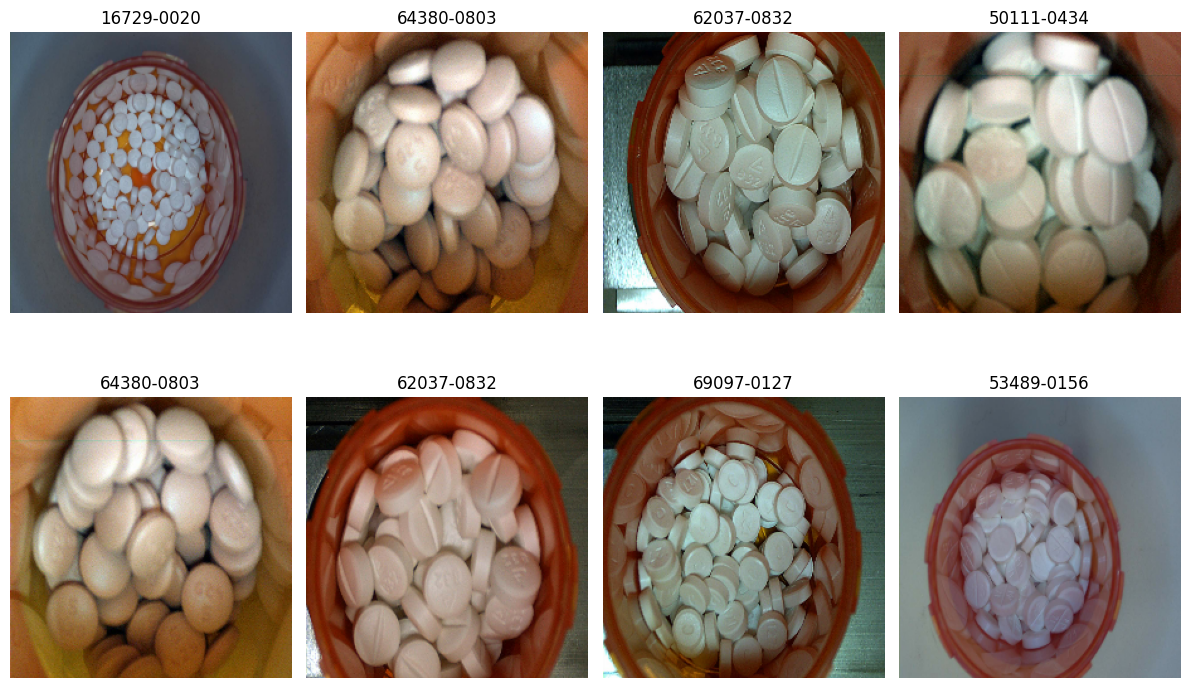

In [6]:
plt.figure(figsize=(12,8))
for images, labels in train_ds.take(1):
    for i in range(min(8,len(images))):
        ax = plt.subplot(2,4,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[np.argmax(labels[i].numpy())])
        plt.axis('off')
plt.tight_layout()
plt.show()


### 2.5 Visualize Images After Augmentation


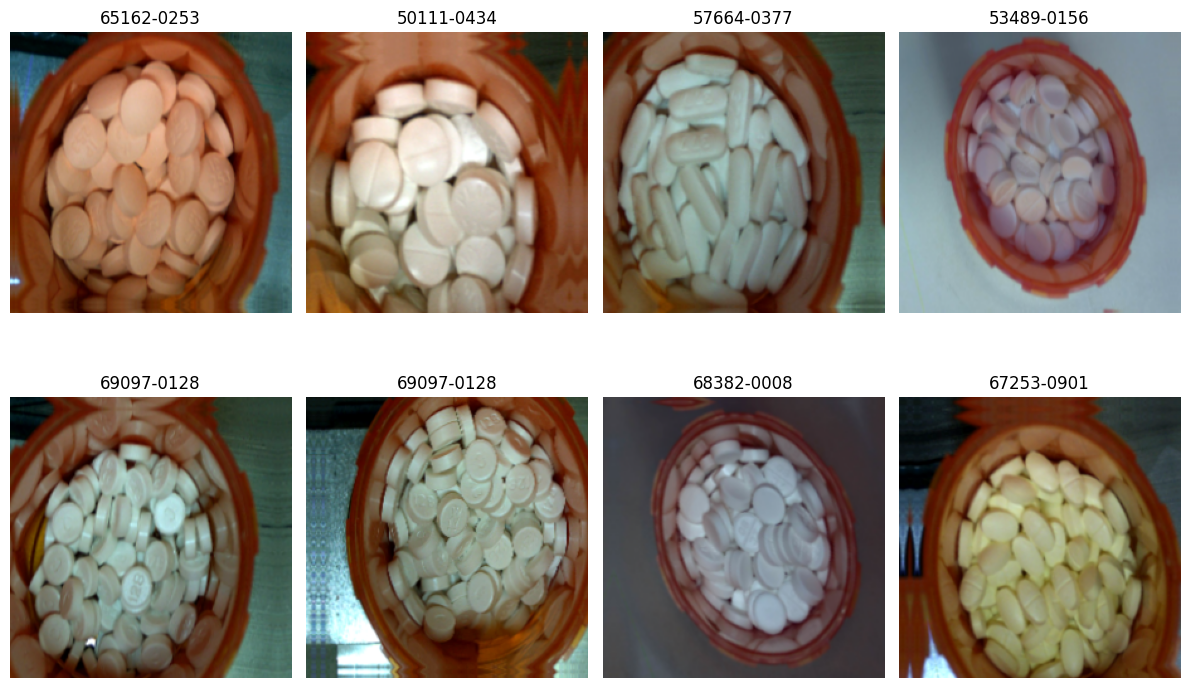

In [7]:
plt.figure(figsize=(12,8))
for images, labels in train_ds.take(1):
    augmented_images = data_augmentation(images, training=True)
    for i in range(min(8,len(augmented_images))):
        ax = plt.subplot(2,4,i+1)
        plt.imshow(tf.clip_by_value(augmented_images[i],0,255).numpy().astype('uint8'))
        plt.title(class_names[np.argmax(labels[i].numpy())])
        plt.axis('off')
plt.tight_layout()
plt.show()


### 2.6 MobileNetV2 Preprocessing


In [8]:
# MobileNetV2 preprocessing maps pixel values to approximately [-1, 1]
AUTOTUNE = tf.data.AUTOTUNE
def preprocess_for_model(image,label):
    image = tf.cast(image,tf.float32)
    image = preprocess_input(image)
    return image,label
def augment_and_preprocess(image,label):
    image = data_augmentation(image,training=True)
    image = tf.cast(image,tf.float32)
    image = preprocess_input(image)
    return image,label
train_ds_v2 = train_ds.map(augment_and_preprocess,num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds_v2 = val_ds.map(preprocess_for_model,num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds_v2 = test_ds.map(preprocess_for_model,num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


## 3. Build MobileNetV2 Model


### 3.1 Load Frozen MobileNetV2 Backbone


In [9]:
# Load MobileNetV2 with pre-trained ImageNet weights
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False
print('Backbone trainable:', base_model.trainable)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Backbone trainable: False


### 3.2 Classification Head


In [10]:
# Same classification head used for the MobileNetV1 baseline
feature_vector = GlobalAveragePooling2D()(base_model.output)
dense_layer = Dense(128)(feature_vector)
batch_norm_layer = BatchNormalization()(dense_layer)
activation_layer = ReLU()(batch_norm_layer)
dropout_layer = Dropout(0.2)(activation_layer)
output_layer = Dense(NUM_CLASSES, activation='softmax')(dropout_layer)


### 3.3 Create Model


In [11]:
model_v2 = Model(inputs=base_model.input, outputs=output_layer, name='MobileNetV2_Frozen')


### 3.4 Metrics


In [12]:
metrics=[
    keras.metrics.CategoricalAccuracy(name='accuracy'),
    keras.metrics.Precision(name='precision'),
    keras.metrics.Recall(name='recall'),
    keras.metrics.F1Score(name='f1-score', average='weighted')
]


### 3.5 Compile Model


In [13]:
model_v2.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=metrics)


### 3.6 Model Summary


In [14]:
model_v2.summary()


Model: "MobileNetV2_Frozen"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,425,044 (9.25 MB)

 Trainable params: 166,804 (651.58 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

### 3.7 Callbacks


In [15]:
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


## 4. Train MobileNetV2


In [16]:
history_v2 = model_v2.fit(train_ds_v2, validation_data=val_ds_v2, epochs=EPOCHS, verbose=1, class_weight=class_weights, callbacks=[reduce_lr,early_stopping])


Epoch 1/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 2350s 9s/step - accuracy: 0.3906 - f1-score: 0.4053 - loss: 1.9699 - precision: 0.8363 - recall: 0.1236 - val_accuracy: 0.5411 - val_f1-score: 0.5223 - val_loss: 1.5223 - val_precision: 0.8467 - val_recall: 0.2089 - learning_rate: 1.0000e-04
Epoch 2/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 180s 683ms/step - accuracy: 0.6613 - f1-score: 0.6633 - loss: 1.1290 - precision: 0.8581 - recall: 0.3630 - val_accuracy: 0.6531 - val_f1-score: 0.6527 - val_loss: 1.1268 - val_precision: 0.8767 - val_recall: 0.3664 - learning_rate: 1.0000e-04
Epoch 3/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 176s 668ms/step - accuracy: 0.7242 - f1-score: 0.7258 - loss: 0.8990 - precision: 0.8544 - recall: 0.4948 - val_accuracy: 0.7053 - val_f1-score: 0.7032 - val_loss: 0.9387 - val_precision: 0.8901 - val_recall: 0.4755 - learning_rate: 1.0000e-04
Epoch 4/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 204s 675ms/step - accuracy: 0.7485 - f1-score: 0.7506 - loss: 0.7777 - precision: 0.8563 - recall: 0.5749 

## 5. Training Curves


### 5.1 Accuracy


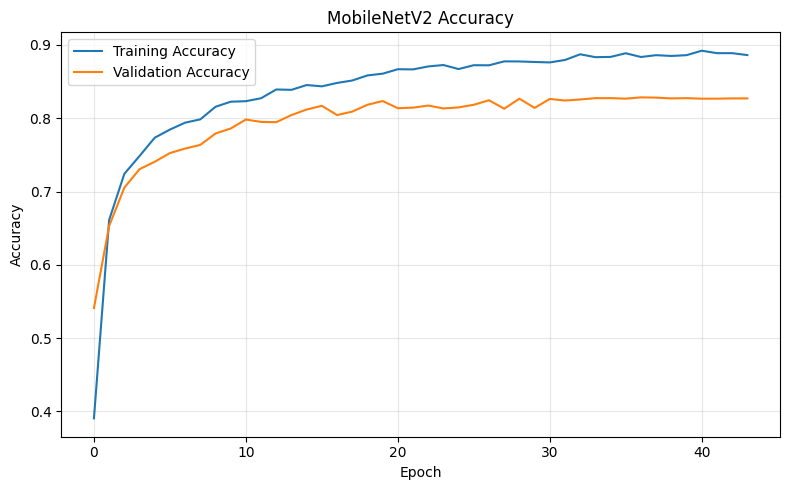

In [17]:
plt.figure(figsize=(8,5))
plt.plot(history_v2.history['accuracy'], label='Training Accuracy')
plt.plot(history_v2.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 5.2 Precision


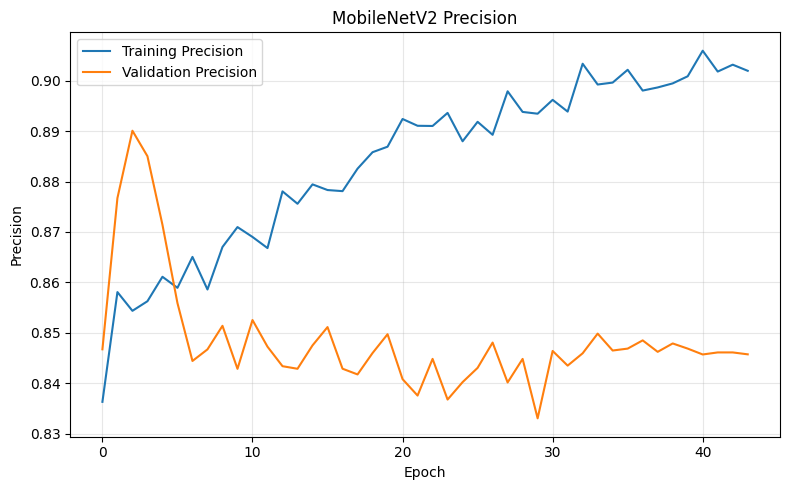

In [18]:
plt.figure(figsize=(8,5))
plt.plot(history_v2.history['precision'], label='Training Precision')
plt.plot(history_v2.history['val_precision'], label='Validation Precision')
plt.title('MobileNetV2 Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 5.3 Recall


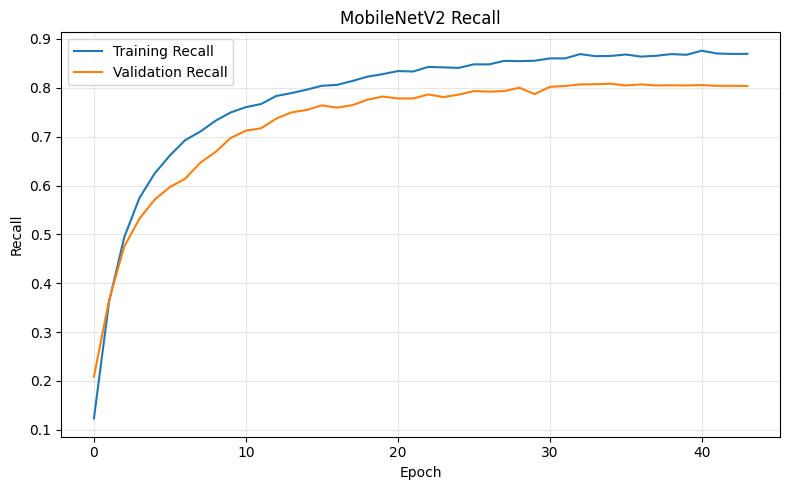

In [19]:
plt.figure(figsize=(8,5))
plt.plot(history_v2.history['recall'], label='Training Recall')
plt.plot(history_v2.history['val_recall'], label='Validation Recall')
plt.title('MobileNetV2 Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 5.4 F1-Score


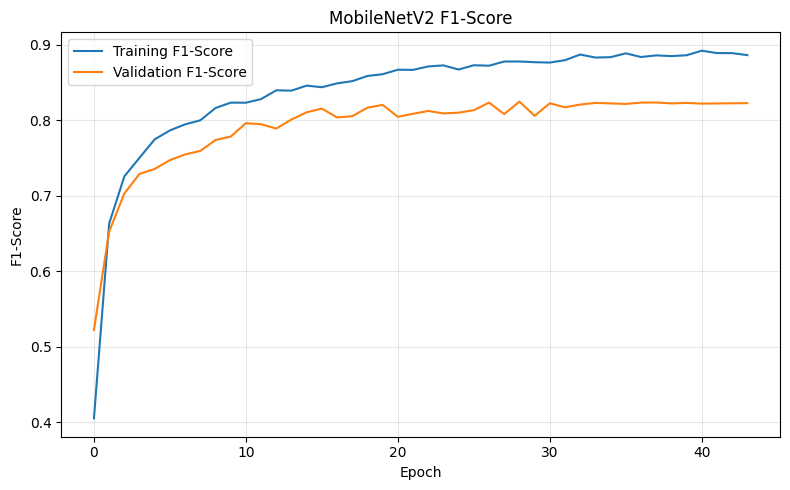

In [20]:
plt.figure(figsize=(8,5))
plt.plot(history_v2.history['f1-score'], label='Training F1-Score')
plt.plot(history_v2.history['val_f1-score'], label='Validation F1-Score')
plt.title('MobileNetV2 F1-Score')
plt.xlabel('Epoch')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 5.5 Loss


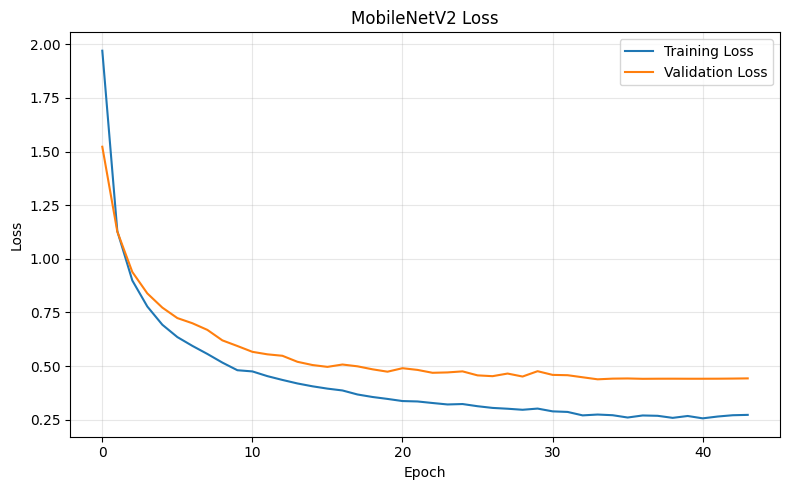

In [21]:
plt.figure(figsize=(8,5))
plt.plot(history_v2.history['loss'], label='Training Loss')
plt.plot(history_v2.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Validation Evaluation


### 6.1 Validation Predictions


In [22]:
y_val_true = []
for images,labels in val_ds_v2:
    y_val_true.extend(np.argmax(labels.numpy(),axis=1))
y_val_true = np.array(y_val_true)
y_val_prob = model_v2.predict(val_ds_v2)
y_val_pred = np.argmax(y_val_prob,axis=1)


87/87 ━━━━━━━━━━━━━━━━━━━━ 27s 252ms/step


### 6.2 Validation Metrics


In [36]:
val_accuracy = accuracy_score(y_val_true,y_val_pred)
val_precision = precision_score(y_val_true,y_val_pred,average='weighted',zero_division=0)
val_recall = recall_score(y_val_true,y_val_pred,average='weighted',zero_division=0)
val_f1 = f1_score(y_val_true,y_val_pred,average='weighted',zero_division=0)
val_macro_f1 = f1_score(y_val_true,y_val_pred,average='macro',zero_division=0)
print('Validation Accuracy:',round(val_accuracy,4))
print('Validation Precision:',round(val_precision,4))
print('Validation Recall:',round(val_recall,4))
print('Validation Weighted F1-Score:',round(val_f1,4))
print('Validation Macro F1-Score:',round(val_macro_f1,4))


Validation Accuracy: 0.8274
Validation Precision: 0.8455
Validation Recall: 0.8274
Validation Weighted F1-Score: 0.8232
Validation Macro F1-Score: 0.8011


### 6.3 Validation Classification Report


In [38]:
print(classification_report(y_val_true, y_val_pred, target_names=class_names, digits=4, zero_division=0))

              precision    recall  f1-score   support

  00378-0208     0.9409    0.8794    0.9091       199
  00378-3855     0.7931    0.5476    0.6479        42
  00591-0461     0.8182    0.5625    0.6667        48
  16729-0020     0.9077    0.7024    0.7919        84
  16729-0168     0.8947    0.8095    0.8500        42
  50111-0434     0.8942    0.9347    0.9140       199
  53489-0156     0.8085    0.5700    0.6686       200
  53746-0544     0.7778    0.6774    0.7241        31
  57664-0377     0.9801    0.9899    0.9850       199
  62037-0831     0.9341    0.7800    0.8501       200
  62037-0832     0.7982    0.8700    0.8325       200
  64380-0803     1.0000    1.0000    1.0000       181
  65162-0253     0.9944    0.9728    0.9835       184
  67253-0901     1.0000    0.9878    0.9939       164
  68382-0008     0.6582    0.9281    0.7701       139
  68382-0227     0.5143    0.9231    0.6606        39
  69097-0127     0.5811    0.8600    0.6935       200
  69097-0128     0.7500    

### 6.4 Validation Confusion Matrix


In [ ]:
cm_val = confusion_matrix(y_val_true,y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_val,display_labels=class_names)
fig,ax = plt.subplots(figsize=(16,14))
disp.plot(ax=ax,cmap='Blues',values_format='d',xticks_rotation=90)
ax.set_title('MobileNetV2 — Validation Confusion Matrix',fontsize=14,fontweight='bold')
ax.set_xlabel('Predicted NDC')
ax.set_ylabel('True NDC')
plt.tight_layout()
plt.show()


## 7. Final Test Evaluation
Run this section **only after MobileNetV2 is finalized based on validation performance**.


### 7.1 Test Predictions


In [26]:
y_test_true = []
for images,labels in test_ds_v2:
    y_test_true.extend(np.argmax(labels.numpy(),axis=1))
y_test_true = np.array(y_test_true)
y_test_prob = model_v2.predict(test_ds_v2)
y_test_pred = np.argmax(y_test_prob,axis=1)


88/88 ━━━━━━━━━━━━━━━━━━━━ 28s 317ms/step


### 7.2 Test Metrics


In [27]:
test_accuracy = accuracy_score(y_test_true,y_test_pred)
test_precision = precision_score(y_test_true,y_test_pred,average='weighted',zero_division=0)
test_recall = recall_score(y_test_true,y_test_pred,average='weighted',zero_division=0)
test_f1 = f1_score(y_test_true,y_test_pred,average='weighted',zero_division=0)
test_macro_f1 = f1_score(y_test_true,y_test_pred,average='macro',zero_division=0)
print('Test Accuracy:',round(test_accuracy,4))
print('Test Precision:',round(test_precision,4))
print('Test Recall:',round(test_recall,4))
print('Test Weighted F1-Score:',round(test_f1,4))
print('Test Macro F1-Score:',round(test_macro_f1,4))


Test Accuracy: 0.8223
Test Precision: 0.8396
Test Recall: 0.8223
Test Weighted F1-Score: 0.818
Test Macro F1-Score: 0.7975


### 7.3 Test Classification Report


In [35]:
# Test classification report
print(classification_report(y_test_true, y_test_pred, target_names=class_names, digits=4, zero_division=0))

              precision    recall  f1-score   support

  00378-0208     0.9389    0.8450    0.8895       200
  00378-3855     0.9259    0.5952    0.7246        42
  00591-0461     0.6667    0.5000    0.5714        48
  16729-0020     0.9444    0.6000    0.7338        85
  16729-0168     0.8636    0.9048    0.8837        42
  50111-0434     0.8733    0.9650    0.9169       200
  53489-0156     0.8176    0.6050    0.6954       200
  53746-0544     0.7059    0.7500    0.7273        32
  57664-0377     1.0000    0.9850    0.9924       200
  62037-0831     0.9490    0.7450    0.8347       200
  62037-0832     0.7589    0.8500    0.8019       200
  64380-0803     1.0000    1.0000    1.0000       182
  65162-0253     0.9946    0.9892    0.9919       185
  67253-0901     0.9940    1.0000    0.9970       165
  68382-0008     0.7097    0.9429    0.8098       140
  68382-0227     0.5072    0.8974    0.6481        39
  69097-0127     0.5517    0.8000    0.6531       200
  69097-0128     0.6700    

### 7.4 Test Confusion Matrix


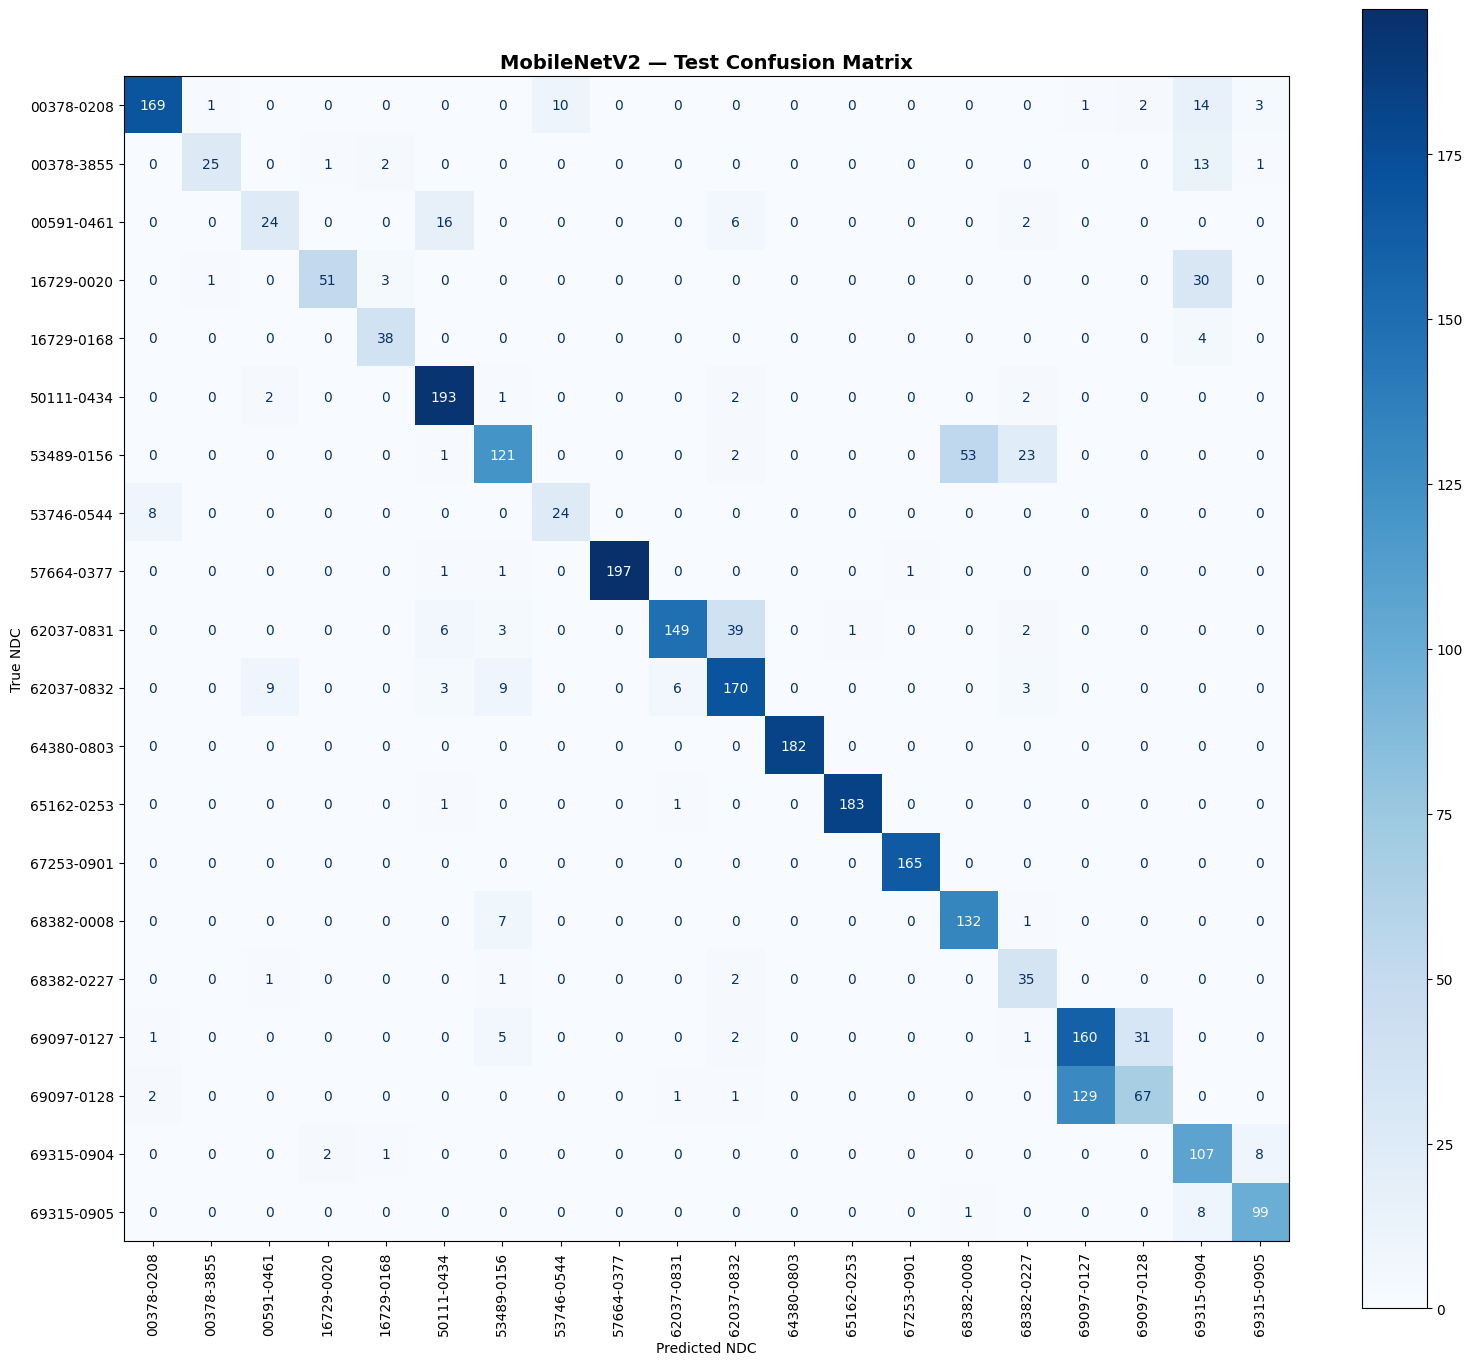

In [29]:
cm_test = confusion_matrix(y_test_true,y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test,display_labels=class_names)
fig,ax = plt.subplots(figsize=(16,14))
disp.plot(ax=ax,cmap='Blues',values_format='d',xticks_rotation=90)
ax.set_title('MobileNetV2 — Test Confusion Matrix',fontsize=14,fontweight='bold')
ax.set_xlabel('Predicted NDC')
ax.set_ylabel('True NDC')
plt.tight_layout()
plt.show()


## 8. Save Model and Results


### 8.1 Save Final Model


In [30]:
model_v2.save(MODEL_DIR / 'MobileNetV2_Frozen.keras')
print('Model saved successfully.')


Model saved successfully.


### 8.2 Save Training History


In [31]:
history_df = pd.DataFrame(history_v2.history)
history_df.to_csv(MODEL_DIR / 'MobileNetV2_Training_History.csv',index=False)
display(history_df.tail())


,accuracy,f1-score,loss,precision,recall,val_accuracy,val_f1-score,val_loss,val_precision,val_recall,learning_rate
39,0.886096,0.886398,0.267493,0.900891,0.867509,0.827450,0.823235,0.441105,0.846854,0.804755,4.000000e-06
40,0.892172,0.892422,0.256540,0.905965,0.875849,0.826729,0.822333,0.441098,0.845688,0.805476,8.000000e-07
41,0.888836,0.889283,0.265000,0.901828,0.870130,0.826729,0.822540,0.441304,0.846096,0.804035,8.000000e-07
42,0.888836,0.889215,0.271031,0.903194,0.869296,0.827089,0.822745,0.441875,0.846096,0.804035,8.000000e-07
43,0.886215,0.886597,0.272699,0.901978,0.869415,0.827089,0.822900,0.442742,0.845716,0.803674,1.600000e-07


### 8.3 Save Validation Results


In [40]:
validation_results = pd.DataFrame({
    'Model':['MobileNetV2 Frozen'],
    'Accuracy':[val_accuracy],
    'Precision':[val_precision],
    'Recall':[val_recall],
    'Weighted F1-Score':[val_f1],
    'Macro F1-Score':[val_macro_f1]
})
validation_results.to_csv(MODEL_DIR / 'MobileNetV2_Validation_Results.csv',index=False)
display(validation_results)


,Model,Accuracy,Precision,Recall,Weighted F1-Score,Macro F1-Score
0,MobileNetV2 Frozen,0.82745,0.845504,0.82745,0.823228,0.801076


### 8.4 Save Test Results


In [39]:
test_results = pd.DataFrame({
    'Model':['MobileNetV2 Frozen'],
    'Accuracy':[test_accuracy],
    'Precision':[test_precision],
    'Recall':[test_recall],
    'Weighted F1-Score':[test_f1],
    'Macro F1-Score':[test_macro_f1]
})
test_results.to_csv(MODEL_DIR / 'MobileNetV2_Test_Results.csv',index=False)
display(test_results)


,Model,Accuracy,Precision,Recall,Weighted F1-Score,Macro F1-Score
0,MobileNetV2 Frozen,0.822326,0.839598,0.822326,0.817989,0.797511


## 9. MobileNetV1 vs MobileNetV2 Comparison


In [34]:
comparison = pd.DataFrame({
    'Model':['MobileNetV1 Frozen','MobileNetV2 Frozen'],
    'Test Accuracy':[0.8916,test_accuracy],
    'Test Weighted F1':[0.8920,test_f1],
    'Test Macro F1':[0.8764,test_macro_f1]
})
display(comparison)


,Model,Test Accuracy,Test Weighted F1,Test Macro F1
0,MobileNetV1 Frozen,0.891600,0.892000,0.876400
1,MobileNetV2 Frozen,0.822326,0.817989,0.797511
